## TUGAS PROYEK KELOMPOK 1 (P1)
### Evaluasi Kinerja Model Klasifikasi

#### Kelompok 2
1. Galih Najwa Pradipta (245150200111009)
2. Muhammad Fahmi Yakhsya (245150200111011)
3. Anasya Laili Rahmadani (245150200111013)
4. Nayla Masyitha Ramadhani (245150200111016)
5. Hassan Nashrallah (245150200111025)

### 1) Import Dataset
Dataset yang kami pilih adalah Bank Marketing Dataset yang diperoleh dari UCI Machine Learning Repository.

In [1]:
! wget https://raw.githubusercontent.com/cirenexus/Vertex-AI-Tutorial-bank_marketing_campaign/main/data/bank.csv

'wget' is not recognized as an internal or external command,
operable program or batch file.


In [1]:
# Explorasi Data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing Data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Model Klasifikasi
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Tuning Data
from sklearn.model_selection import GridSearchCV

# Evaluasi Model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score
)

### 2) Eksplorasi dan Pemahaman Data

===== 5 Data Pertama =====
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  

===== Shape Dataset =====
(11162, 17)

===== Informasi Dataset =====
<c

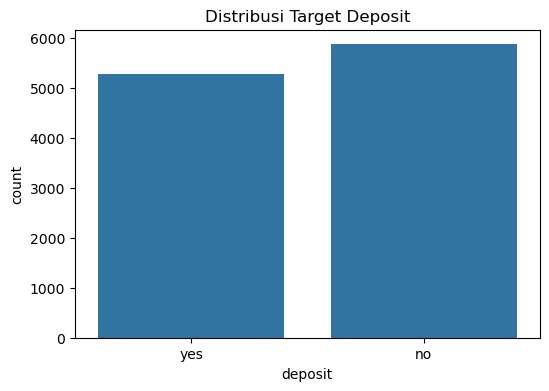


Fitur Numerik: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Fitur Kategorikal: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'deposit']


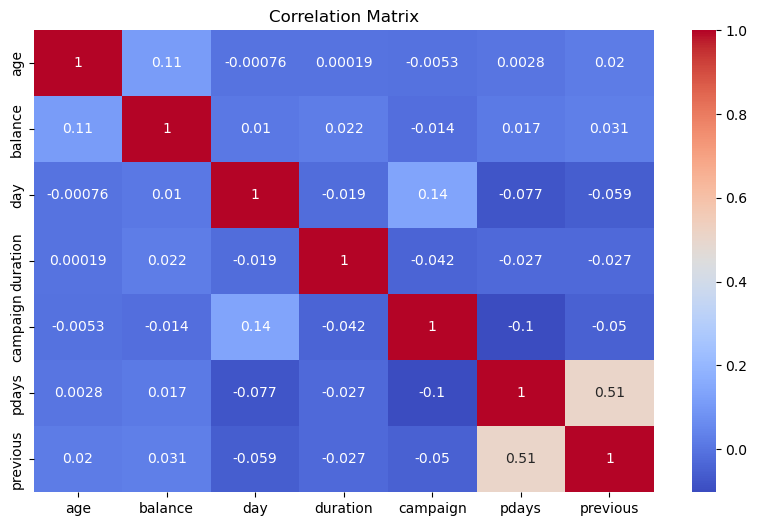

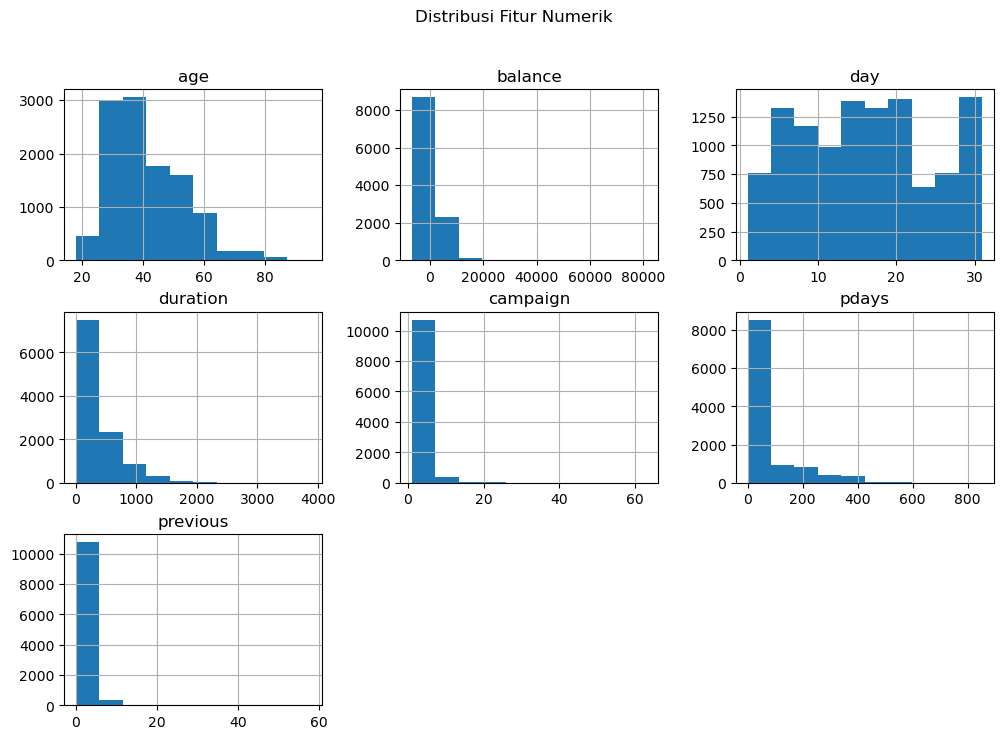

In [2]:
data = pd.read_csv("C:/Users/hassa/OneDrive/Dokumen/praktikumz/kal-praktikum/data/bank.csv")
# data = data.drop('id', axis=1)

# 1. Melihat 5 data pertama
print("===== 5 Data Pertama =====")
print(data.head())

# 2. Ukuran dataset
print("\n===== Shape Dataset =====")
print(data.shape)

# 3. Informasi dataset
print("\n===== Informasi Dataset =====")
print(data.info())

# 4. Statistik deskriptif
print("\n===== Statistik Dataset =====")
print(data.describe(include="all"))

# 5. Missing value
print("\n===== Missing Value =====")
print(data.isnull().sum())

# 6. Distribusi target
print("\n===== Distribusi Target (deposit) =====")
print(data['deposit'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=data)
plt.title("Distribusi Target Deposit")
plt.show()

# 7. Identifikasi fitur numerik dan kategorikal
numerical_features = data.select_dtypes(include=['int64','float64']).columns
categorical_features = data.select_dtypes(include=['object']).columns

print("\nFitur Numerik:", list(numerical_features))
print("Fitur Kategorikal:", list(categorical_features))

# 8. Korelasi fitur numerik
plt.figure(figsize=(10,6))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# 9. Distribusi fitur numerik
data[numerical_features].hist(figsize=(12,8))
plt.suptitle("Distribusi Fitur Numerik")
plt.show()

### 3) Data Preprocessing

In [3]:
# 1. Pisahkan fitur dan target
X = data.drop("deposit", axis=1)
y = data["deposit"]

# 2. Encode target (yes/no --> 1/0)
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Train-Val-Test Split: 70% - 15% - 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42,
    stratify=y
)

# 15/85 +- 0.176 dari temp --> menghasilkan 15% dari total
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

# 4. Identifikasi fitur numerik dan kategorikal
numerical_features = X.select_dtypes(include=['int64','float64']).columns
categorical_features = X.select_dtypes(include=['object']).columns

# 5. Pipeline numerik
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# 6. Pipeline kategorikal
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 7. ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_features),
    ("cat", cat_pipeline, categorical_features)
])

print("Shape data train :", X_train.shape)
print("Shape data val :", X_val.shape)
print("Shape data test :", X_test.shape)

Shape data train : (7817, 16)
Shape data val : (1670, 16)
Shape data test : (1675, 16)


### 4) Model Klasifikasi

#### Model Klasifikasi – KNN

Accuracy KNN: 0.8119402985074626

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       881
           1       0.82      0.78      0.80       794

    accuracy                           0.81      1675
   macro avg       0.81      0.81      0.81      1675
weighted avg       0.81      0.81      0.81      1675



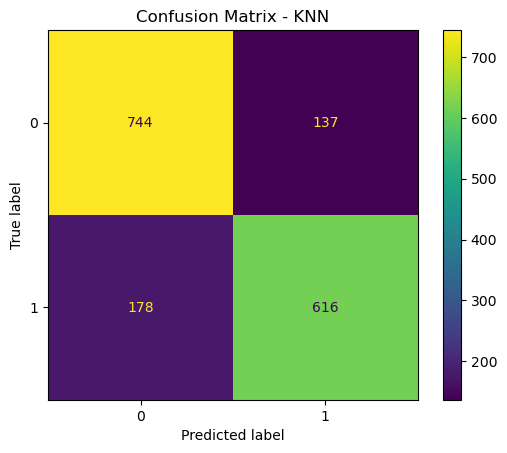

In [4]:
# Pipeline KNN
knn_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

# Training model
knn_model.fit(X_train, y_train)

# Prediksi data test
y_pred_knn = knn_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy KNN:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - KNN")
plt.show()

#### Model Klasifikasi – Random Forest

Accuracy Random Forest: 0.8608955223880597

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.83      0.86       881
           1       0.82      0.90      0.86       794

    accuracy                           0.86      1675
   macro avg       0.86      0.86      0.86      1675
weighted avg       0.86      0.86      0.86      1675



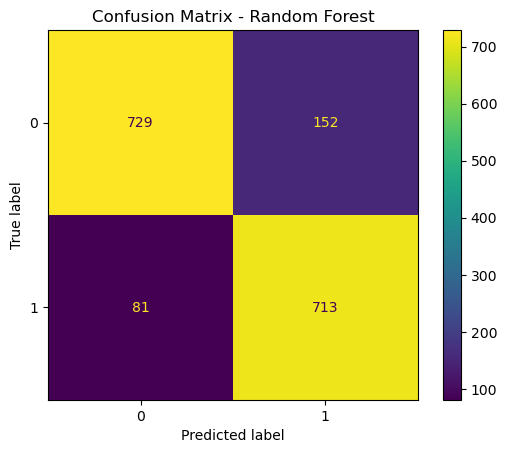

In [5]:
# Pipeline Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Training model
rf_model.fit(X_train, y_train)

# Prediksi data test
y_pred_rf = rf_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_rf)

print("Accuracy Random Forest:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

#### Model Klasifikasi – SVM

Accuracy SVM: 0.8549253731343284

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       881
           1       0.83      0.87      0.85       794

    accuracy                           0.85      1675
   macro avg       0.85      0.86      0.85      1675
weighted avg       0.86      0.85      0.86      1675



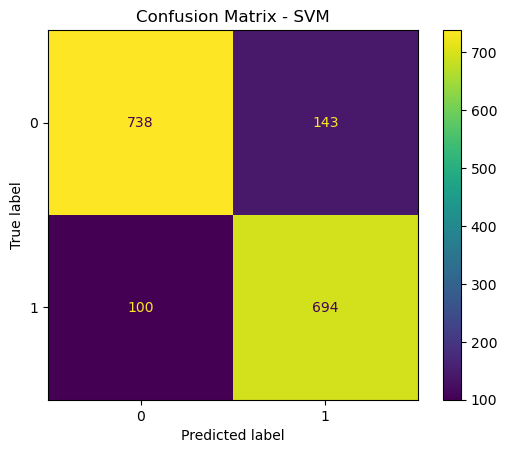

In [6]:
# Pipeline SVM
svm_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(random_state=42, probability=True))
])

# Training model
svm_model.fit(X_train, y_train)

# Prediksi data test
y_pred_svm = svm_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_svm)

print("Accuracy SVM:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVM")
plt.show()

### 5) Tuning Hyperparameter

#### Tuning – KNN

Best CV Score: 0.8056804329008578
Accuracy KNN (Tuned): 0.817910447761194

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       881
           1       0.82      0.78      0.80       794

    accuracy                           0.82      1675
   macro avg       0.82      0.82      0.82      1675
weighted avg       0.82      0.82      0.82      1675



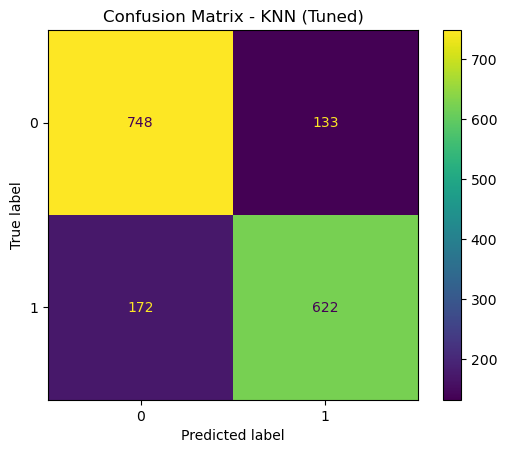

In [7]:
# Pipeline KNN
knn_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier())
])

# Parameter grid untuk tuning KNN
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 15],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'minkowski']
}

# GridSearchCV
knn_grid = GridSearchCV(
    knn_pipeline,
    param_grid_knn,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Training model dengan GridSearch
knn_grid.fit(X_train, y_train)

# Model terbaik
best_knn_model = knn_grid.best_estimator_

# Prediksi data test
y_pred_knn = best_knn_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_knn)

print("Best CV Score:", knn_grid.best_score_)
print("Accuracy KNN (Tuned):", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - KNN (Tuned)")
plt.show()

#### Tuning – Random Forest

Best CV Score: 0.8504526019704386
Accuracy Random Forest (Tuned): 0.8531343283582089

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.81      0.85       881
           1       0.81      0.90      0.85       794

    accuracy                           0.85      1675
   macro avg       0.86      0.86      0.85      1675
weighted avg       0.86      0.85      0.85      1675



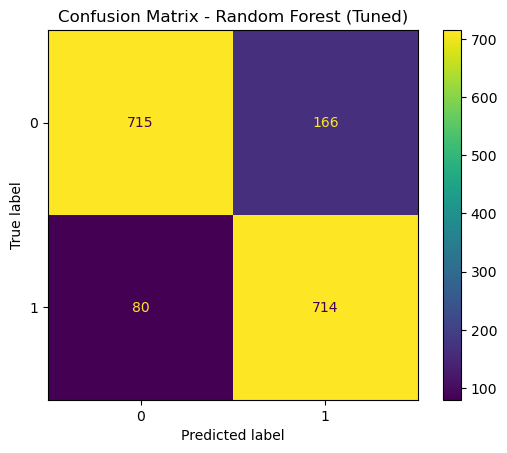

In [8]:
# Pipeline Random Forest
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Parameter grid untuk tuning
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

# GridSearchCV
rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Training model dengan GridSearch
rf_grid.fit(X_train, y_train)

# Model terbaik
best_rf_model = rf_grid.best_estimator_

# Prediksi data test
y_pred_rf = best_rf_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_rf)

print("Best CV Score:", rf_grid.best_score_)
print("Accuracy Random Forest (Tuned):", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Tuned)")
plt.show()

#### Tuning – SVM

Best CV Score: 0.8505807246540442
Accuracy SVM (Tuned): 0.8567164179104477

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.84      0.86       881
           1       0.83      0.88      0.85       794

    accuracy                           0.86      1675
   macro avg       0.86      0.86      0.86      1675
weighted avg       0.86      0.86      0.86      1675



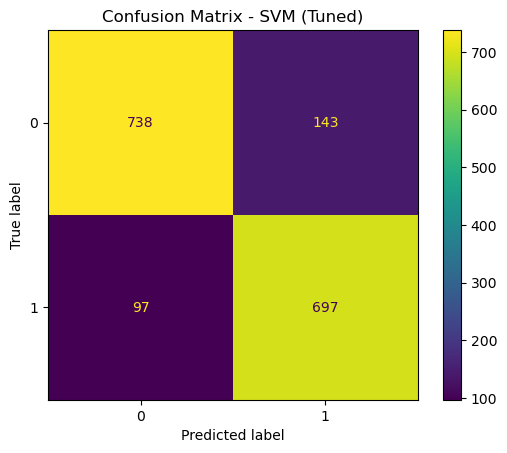

In [9]:
# Pipeline SVM
svm_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", SVC(probability=True, random_state=42))
])

# Parameter grid untuk tuning
param_grid_svm = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': ['scale', 'auto', 0.1],
    'classifier__kernel': ['rbf', 'poly']
}

# GridSearchCV
svm_grid = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Training model dengan GridSearch
svm_grid.fit(X_train, y_train)

# Model terbaik
best_svm_model = svm_grid.best_estimator_

# Prediksi data test
y_pred_svm = best_svm_model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred_svm)

print("Best CV Score:", svm_grid.best_score_)
print("Accuracy SVM (Tuned):", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - SVM (Tuned)")
plt.show()

### 6) Evaluasi Model

In [10]:
def evaluate_model(y_true, y_pred, y_prob=None):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    if y_prob is not None:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = None

    return acc, prec, rec, f1, auc

In [11]:
# List untuk menyimpan semua hasil
hasil_evaluasi = []

# Dictionary berisi pasangan model (sebelum tuning vs sesudah tuning)
kumpulan_model = {
    "KNN": (knn_model, best_knn_model),
    "Random Forest": (rf_model, best_rf_model),
    "SVM": (svm_model, best_svm_model)
}

# Looping untuk menghitung metrik semua model
for nama_model, (model_base, model_tuned) in kumpulan_model.items():

    # --- Evaluasi Sebelum Tuning ---
    y_pred_base = model_base.predict(X_test)
    y_prob_base = model_base.predict_proba(X_test)[:, 1]
    acc, prec, rec, f1, auc = evaluate_model(y_test, y_pred_base, y_prob_base)

    hasil_evaluasi.append({
        'Model': nama_model,
        'Status': 'Sebelum Tuning',
        'Akurasi': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

    # --- Evaluasi Setelah Tuning ---
    y_pred_tuned = model_tuned.predict(X_test)
    y_prob_tuned = model_tuned.predict_proba(X_test)[:, 1]
    acc_t, prec_t, rec_t, f1_t, auc_t = evaluate_model(y_test, y_pred_tuned, y_prob_tuned)

    hasil_evaluasi.append({
        'Model': nama_model,
        'Status': 'Setelah Tuning',
        'Akurasi': acc_t,
        'Precision': prec_t,
        'Recall': rec_t,
        'F1-Score': f1_t,
        'ROC-AUC': auc_t
    })

# Tabel DataFrame
df_evaluasi = pd.DataFrame(hasil_evaluasi)
print("===== TABEL PERBANDINGAN PERFORMA MODEL =====")
display(df_evaluasi)

===== TABEL PERBANDINGAN PERFORMA MODEL =====


,Model,Status,Akurasi,Precision,Recall,F1-Score,ROC-AUC
0,KNN,Sebelum Tuning,0.811940,0.818061,0.775819,0.796380,0.882698
1,KNN,Setelah Tuning,0.817910,0.823841,0.783375,0.803099,0.900497
2,Random Forest,Sebelum Tuning,0.860896,0.824277,0.897985,0.859554,0.924038
3,Random Forest,Setelah Tuning,0.853134,0.811364,0.899244,0.853047,0.924948
4,SVM,Sebelum Tuning,0.854925,0.829152,0.874055,0.851012,0.922819
5,SVM,Setelah Tuning,0.856716,0.829762,0.877834,0.853121,0.926230


### 7) Analisis Hasil

In [ ]:
df_evaluasi = pd.DataFrame(hasil_evaluasi)

# Ubah status menjadi 'Baseline' / 'Tuned' dan buat kolom index
df_evaluasi['Model_Status'] = df_evaluasi['Model'] + ' ' + df_evaluasi['Status'].replace({
    'Sebelum Tuning': 'Baseline',
    'Setelah Tuning': 'Tuned'
})

# Pivot ke bentuk table dengan index Model_Status
df_comparison = df_evaluasi.set_index('Model_Status')[['Akurasi', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].round(4)

# 1. Analisis Model Terbaik
print("\n1. MODEL TERBAIK")
print("-" * 40)
best_model = df_comparison['F1-Score'].idxmax()
print(f"   Model terbaik berdasarkan F1-Score adalah: {best_model}")
print(f"   Accuracy : {df_comparison.loc[best_model, 'Akurasi']:.4f}")
print(f"   Precision: {df_comparison.loc[best_model, 'Precision']:.4f}")
print(f"   Recall   : {df_comparison.loc[best_model, 'Recall']:.4f}")
print(f"   F1-Score : {df_comparison.loc[best_model, 'F1-Score']:.4f}")
print(f"   ROC-AUC  : {df_comparison.loc[best_model, 'ROC-AUC']:.4f}")
print()

# 2. Pengaruh Preprocessing dan Tuning
print("2. PENGARUH PREPROCESSING & TUNING")
print("-" * 40)

# Pipeline KNN tanpa scaling
preprocessor_no_scaler = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numerical_features),
    ("cat", cat_pipeline, categorical_features)
])
knn_no_scaler = Pipeline([("preprocessor", preprocessor_no_scaler),
                          ("classifier", KNeighborsClassifier(n_neighbors=5))])
knn_no_scaler.fit(X_train, y_train)
y_pred_no_scaler = knn_no_scaler.predict(X_test)
acc_no_scaler = accuracy_score(y_test, y_pred_no_scaler)
print(f"   KNN tanpa scaling: {acc_no_scaler:.3f}")

# Akurasi KNN dengan scaling dari model yang sudah ada (knn_model)
y_pred_scaled = knn_model.predict(X_test)
acc_scaled = accuracy_score(y_test, y_pred_scaled)
print(f"   KNN dengan scaling: {acc_scaled:.3f}")
print(f"   Peningkatan: {(acc_scaled - acc_no_scaler)*100:.1f}%")
print()

# 3. Pengaruh Hyperparameter Tuning
print("3. PENGARUH HYPERPARAMETER TUNING")
print("-" * 40)
for model in ['KNN', 'Random Forest', 'SVM']:
    baseline_key = f"{model} Baseline"
    tuned_key = f"{model} Tuned"
    if baseline_key in df_comparison.index and tuned_key in df_comparison.index:
        delta_f1  = df_comparison.loc[tuned_key, 'F1-Score'] - df_comparison.loc[baseline_key, 'F1-Score']
        delta_auc = df_comparison.loc[tuned_key, 'ROC-AUC']  - df_comparison.loc[baseline_key, 'ROC-AUC']
        print(f"   {model:12s}: F1 {delta_f1:+.4f}  |  AUC {delta_auc:+.4f}")
print()

# 4. Hyperparameter Terbaik
print("4. HYPERMARAMETER TERBAIK")
print("-" * 40)
print("   Parameter Terbaik KNN:", knn_grid.best_params_)
print("   Parameter Terbaik Random Forest:", rf_grid.best_params_)
print("   Parameter Terbaik SVM:", svm_grid.best_params_)
print()

# 5. Feature Importance
print("5. FEATURE IMPORTANCE")
print("-" * 40)
best_rf = best_rf_model
# Ambil nama fitur setelah one-hot encoding
feature_names = (list(numerical_features) +
                 list(best_rf.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .named_steps['encoder']
                      .get_feature_names_out(categorical_features)))

importances = best_rf.named_steps['classifier'].feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top 10 Feature Importance:")
print(feat_imp.head(10))
print()


1. MODEL TERBAIK
----------------------------------------
   Model terbaik berdasarkan F1-Score adalah: Random Forest Baseline
   Accuracy : 0.8609
   Precision: 0.8243
   Recall   : 0.8980
   F1-Score : 0.8596
   ROC-AUC  : 0.9240

2. PENGARUH PREPROCESSING & TUNING
----------------------------------------
   KNN tanpa scaling: 0.747
   KNN dengan scaling: 0.812
   Peningkatan: 6.4%

3. PENGARUH HYPERPARAMETER TUNING
----------------------------------------
   KNN         : F1 +0.0067  |  AUC +0.0178
   Random Forest: F1 -0.0066  |  AUC +0.0009
   SVM         : F1 +0.0021  |  AUC +0.0034

4. HYPERMARAMETER TERBAIK
----------------------------------------
   Parameter Terbaik KNN: {'classifier__metric': 'euclidean', 'classifier__n_neighbors': 15, 'classifier__weights': 'distance'}
   Parameter Terbaik Random Forest: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
   Parameter Terbaik SVM: {'classi